In [2]:
import json

import colorcet
import h5py
import matplotlib.pyplot as plt
import numpy as np

from lib.plots import set_axis
from lib.stats import fit_power_law

In [83]:
config_id = 22
filename = f"_outputs/output-{config_id}.h5"

with h5py.File(filename, "r") as store:
    config = json.loads(store["metadata/config_source"][()])
    config_used = json.loads(store["metadata/config"][()])

    production_overrides = config_used["sampling"]["phases"][-1]
    production_name = production_overrides["name"]
    phase_store = store["phases"][production_name]

    cohesin_history: dict[int, list[tuple[int, int | None]]] = {}
    for step_key in phase_store[".steps"]:
        sample = phase_store[step_key]

        for cohesin_id, (loaded_site, captured_site) in (
            zip(sample["captures/ids"], sample["captures/sites"])
        ):
            if cohesin_id not in cohesin_history:
                cohesin_history[cohesin_id] = []
            if captured_site == loaded_site:
                captured_site = None
            cohesin_history[cohesin_id].append((loaded_site, captured_site))

In [84]:
chain_used, = config_used["chains"]
chain_length = chain_used["length"]
default_valency = config_used["association"]["valency"]

selector_a = np.full(chain_length, False)
for feature in chain_used.get("association_features", []):
    is_a = False
    match feature:
        case {"valency": valency}:
            is_a = (valency < default_valency)

        case {"association": _} | {"dissociation": _}:
            assoc = feature.get("association", 1)
            dissoc = feature.get("dissociation", 1)
            is_a = (assoc < dissoc)

    if is_a:
        site = feature["site"]
        start = site["start"]
        end = site["end"]
        selector_a[start:end] = True

selector_b = ~selector_a

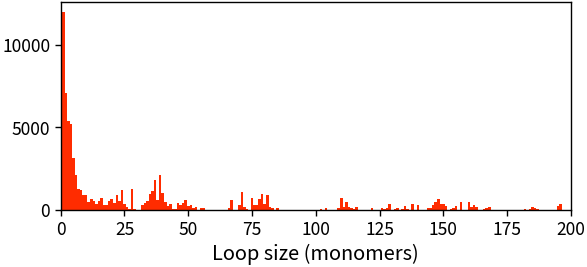

In [85]:
dists = []

for u in cohesin_history.keys():
    x = [i for i, _ in cohesin_history[u]]
    y = [j for _, j in cohesin_history[u]]

    dists.extend([
        abs(i - j)
        for i, j in zip(x, y) if j is not None
    ])

fig, ax = plt.subplots(figsize=(3.0, 1.4))

ax.hist(dists, bins=np.arange(chain_length), align="left", color="C:r")

ax.set_xlabel("Loop size (monomers)")
ax.set_xlim(0, chain_length)

pass

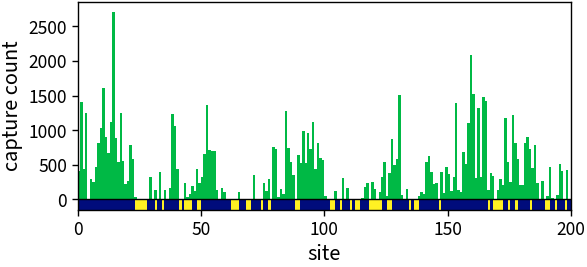

In [86]:
captured_sites = []

for u in cohesin_history.keys():
    captured_sites.extend([j for _, j in cohesin_history[u] if j is not None])

fig, ax = plt.subplots(figsize=(3.0, 1.4))

ax.matshow(
    selector_a[None, :],
    extent=[0, chain_length, -150, 0],
    cmap=colorcet.m_bmy,
    aspect="auto",
)

ax.axhline(0)

ax.hist(
    captured_sites,
    bins=np.arange(0, chain_length),
    color="C:g",
)

set_axis(ax, spines="all", ticks="left bottom")

ax.set_xlabel("site")
ax.set_ylabel("capture count")
ax.set_xlim(0, chain_length)

pass